# Максимален поток (Max Flow) {#sec-max-flow}

Отвори в Colab: [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)]({{< var colabPrefix >}}06-02-Max-Flow-Shortest-Path.ipynb)


In [1]:
#| include: false

import importlib
import importlib.util
import subprocess
import sys
from pathlib import Path

# Install gurobipy only when needed and only in Colab.
if importlib.util.find_spec("gurobipy") is None:
    if "google.colab" in sys.modules:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "gurobipy"])
    else:
        print("gurobipy is not installed. Install it in your local environment.")

# Try local import first; if missing in Colab, clone repo and import from it.
try:
    graphs = importlib.import_module("scripts.graphs")
except ModuleNotFoundError:
    if "google.colab" not in sys.modules:
        raise

    repo_url = "https://github.com/febse/opt2026.git"
    clone_dir = Path("/content/opt2026")

    if not clone_dir.exists():
        subprocess.check_call(["git", "clone", "--depth", "1", repo_url, str(clone_dir)])

    if str(clone_dir) not in sys.path:
        sys.path.insert(0, str(clone_dir))

    graphs = importlib.import_module("scripts.graphs")

print("scripts.graphs imported successfully.")

scripts.graphs imported successfully.


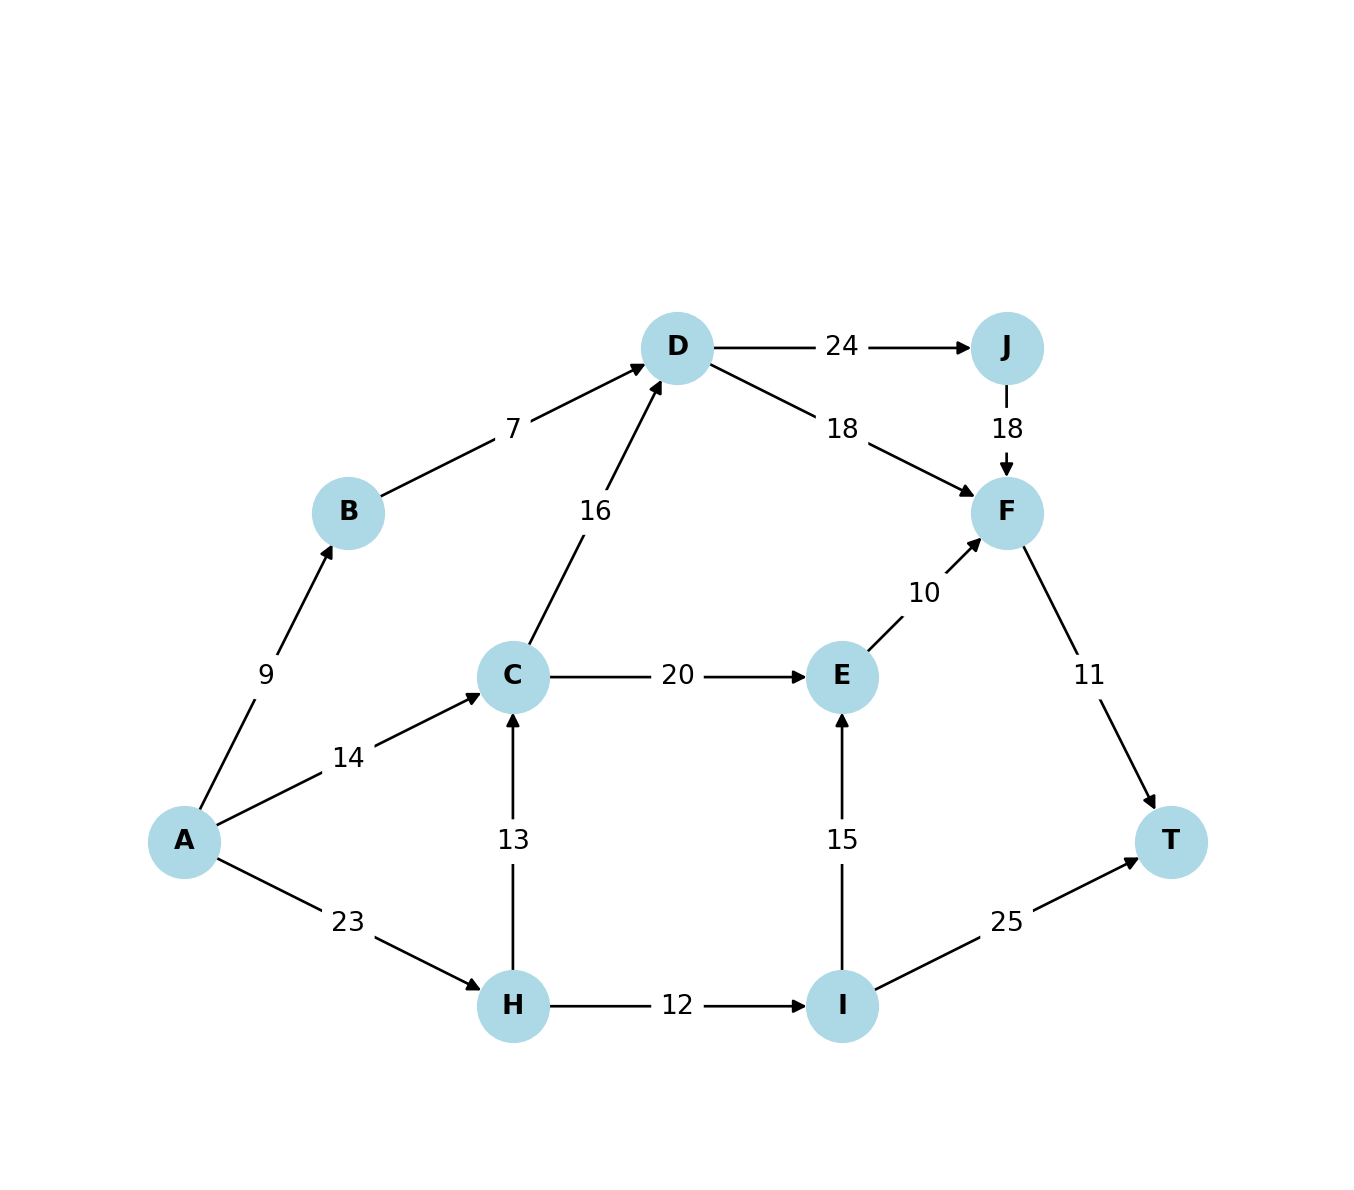

In [2]:
#| label: fig-graph-max-flow
#| fig-cap: "Водопреносна мрежа с капацитети на дъгите с начало в A и край в G. Стойностите на дъгите показват преносния им капацитет."

graphs.visualize_graph("Capacity", title='')


Първо ще разгледаме класически проблем за намиране на най-големия поток в мрежа. Може да си представим, че @fig-graph-max-flow показва мрежа от водопроводни тръби, където всяка дъга има определен капацитет (стойностите на дъгите), който показва максималното количество вода, което може да премине през нея. Целта е да се определи колко вода може да се пренесе от началния възел A (източник, source) до крайния възел T (приемник, sink, target), като се спазват капацитетите на дъгите.

- Формулирайте проблема като задача за линейна оптимизация (LP). Сравнете вашата формулировка със @sec-max-flow-gurobi-model.
- Решете задачата в [Excel](./excel/Max-Flow-Capacities.xlsx) и сравнете резултата си с решението, получено с Gurobi: @sec-max-flow-solution-gurobi

:::{.callout-note collapse="true"}
## Решение

Нека $x_{ij} \geq 0, i,j \in \{A, B, C, D, E, F, H, I, J, T\}$ са променливи, които показват поток с начален връх $i$ и посока $j$. Целта ни е да намерим колко е възможно най-големия поток от източника A към крайната точка T.

Целевата функция е потокът в крайния възел T:

$$
\begin{align*}
\text{Maximize} \quad & x_{FT} + x_{IT}
\end{align*}
$$

Потоците между възлите не могат да надвишават капацитета на съответните дъги (следващите неравенства описват това ограничение за първите три и последните две дъги, останалите са аналогично):

$$
\begin{align*}
x_{AB} &\leq 9 \\
x_{AC} &\leq 14 \\
x_{AH} &\leq 23 \\
\vdots \\
x_{IT} &\leq 25 \\
x_{FT} &\leq 11
\end{align*}
$$

Потоците в мрежата трябва да отговарят и на балансовото ограничение, което гласи, че за всеки възел (освен източника и приемника) сумата от входящите потоци трябва да е равна на сумата от изходящите потоци. Например, за възлите B  и C това означава:

$$
\begin{align*}
x_{АB} & = x_{BD}\\
x_{AC} + x_{HC} & = x_{CD} + x_{CE}
\end{align*}
$$

:::


:::{.callout-note collapse="true"}
## Решение (компактна нотация)

Графът в задачата е напълно описан от множеството на възлите (nodes, N), множеството на дъгите (edges, E) и капацитетите на дъгите (capacities, c).

$$
\begin{align*}
N & = \{A, B, C, D, E, F, H, I, J, T\} \\
E & = \{(A,B), (A,C), (A,H), (B,D), (C,D), (C, E) \ldots, (I,T), (F, T)\} \\
c_{ij} &:  \text{капацитет на дъга } (i,j) \in E
\end{align*}
$$

Нека за всеки връх $i \in N$ дефинираме две множества: $V^+_i$ което съдържа всички дъги, които сочат към $i$ и $V^-_i$ което съдържа всички дъги, които излизат от $i$. Например, за възел $C$ имаме:

$$
\begin{align*}
V^+_C & = \{(A, C), (H, C)\} \\
V^-_C & = \{(C, D), (C, E)\}
\end{align*}
$$

Целевата функция може да се запише като:

$$
\begin{align*}
\text{Maximize} \quad & \sum_{(i,j) \in V^+_T} x_{ij}
\end{align*}
$$

Обърнете внимание, че $V^+_T$ съдържа всички дъги, които сочат към възел T, т.е. $V^+_T = \{(F, T), (I, T)\}$.

Входящите потоци към всеки възел трябва да са равни на изходящите потоци:

$$
\begin{align*}
\sum_{(i,j) \in V^+_k} x_{ij} & = \sum_{(i,j) \in V^-_k} x_{ijW} \quad \forall k \in N \setminus \{A, T\}
\end{align*}
$$

Потоците не могат да надвишават капацитета на съответните дъги:

$$
\begin{align*}
x_{ij} & \leq c_{ij} \quad \forall (i,j) \in E
\end{align*}
$$

:::

In [3]:
import gurobipy as gp
from gurobipy import GRB

G = graphs.G
positions = graphs.positions

mf = gp.Model("MaxFlow")
mf.setParam('LogToConsole', 0)  # Изключваме изхода на Gurobi за по-чист резултат

# Създаваме променливи за поток на всяка дъга
flow = mf.addVars(G.edges(), name="Flow")

# Ограничения за капацитетите на дъгите
for u, v in G.edges():
    mf.addConstr(flow[u, v] <= G.edges[u, v]['Capacity'], name=f"Cap_{u}_{v}")

# Ограничения за запазване на потока (flow conservation)
for node in G.nodes():
    inflow = gp.quicksum(flow[u, node] for u in G.predecessors(node))
    outflow = gp.quicksum(flow[node, v] for v in G.successors(node))
    
    # Само за вътрешни възли, потокът влизащ = потокът излизащ
    if node != 'A' and node != 'T':
        mf.addConstr(inflow == outflow, name=f"FlowConservation_{node}")

# Целева функция: максимизиране на потока от A до T
mf.setObjective(gp.quicksum(flow[v, "T"] for v in G.predecessors("T")), GRB.MAXIMIZE)

mf.optimize()

Restricted license - for non-production use only - expires 2027-11-29


Set parameter LogToConsole to value 0


## Модел в Gurobi {#sec-max-flow-gurobi-model}


In [4]:
mf.write("__max_flow_model.lp")

with open("__max_flow_model.lp", "r") as f:
    print(f.read())

\ Model MaxFlow
\ LP format - for model browsing. Use MPS format to capture full model detail.
Maximize
  Flow[F,T] + Flow[I,T]
Subject To
 Cap_A_B: Flow[A,B] <= 9
 Cap_A_C: Flow[A,C] <= 14
 Cap_A_H: Flow[A,H] <= 23
 Cap_B_D: Flow[B,D] <= 7
 Cap_C_D: Flow[C,D] <= 16
 Cap_C_E: Flow[C,E] <= 20
 Cap_D_F: Flow[D,F] <= 18
 Cap_D_J: Flow[D,J] <= 24
 Cap_E_F: Flow[E,F] <= 10
 Cap_F_T: Flow[F,T] <= 11
 Cap_H_C: Flow[H,C] <= 13
 Cap_H_I: Flow[H,I] <= 12
 Cap_I_E: Flow[I,E] <= 15
 Cap_I_T: Flow[I,T] <= 25
 Cap_J_F: Flow[J,F] <= 18
 FlowConservation_B: Flow[A,B] - Flow[B,D] = 0
 FlowConservation_C: Flow[A,C] - Flow[C,D] - Flow[C,E] + Flow[H,C] = 0
 FlowConservation_D: Flow[B,D] + Flow[C,D] - Flow[D,F] - Flow[D,J] = 0
 FlowConservation_E: Flow[C,E] - Flow[E,F] + Flow[I,E] = 0
 FlowConservation_F: Flow[D,F] + Flow[E,F] - Flow[F,T] + Flow[J,F] = 0
 FlowConservation_H: Flow[A,H] - Flow[H,C] - Flow[H,I] = 0
 FlowConservation_I: Flow[H,I] - Flow[I,E] - Flow[I,T] = 0
 FlowConservation_J: Flow[D,J] - Flo

## Решение с Gurobi {#sec-max-flow-solution-gurobi}

Максимален поток от A до T: 23.0
Поток по дъгата A -> B: 1.0
Поток по дъгата A -> C: 10.0
Поток по дъгата A -> H: 12.0
Поток по дъгата B -> D: 1.0
Поток по дъгата C -> E: 10.0
Поток по дъгата D -> J: 1.0
Поток по дъгата E -> F: 10.0
Поток по дъгата F -> T: 11.0
Поток по дъгата H -> I: 12.0
Поток по дъгата I -> T: 12.0
Поток по дъгата J -> F: 1.0


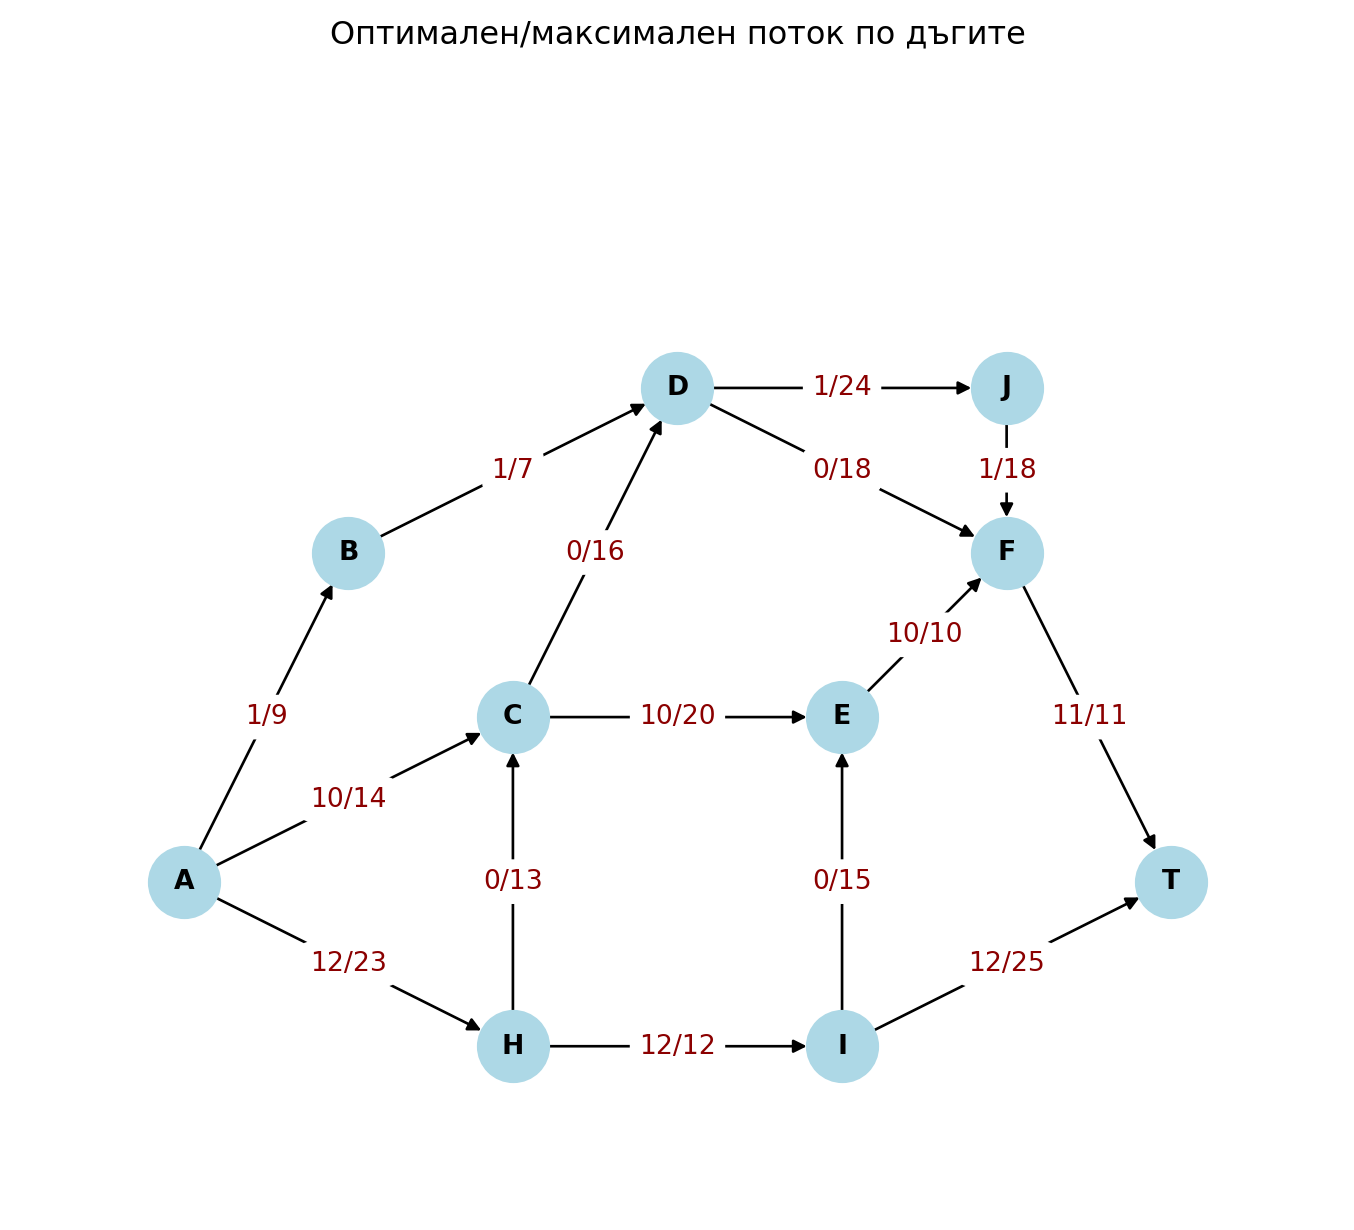

In [5]:
if mf.status == GRB.OPTIMAL:
    print(f"Максимален поток от A до T: {mf.objVal}")
    for u, v in G.edges():
        if flow[u, v].x > 0.01:  # Показваме само значими потоци
            print(f"Поток по дъгата {u} -> {v}: {flow[u, v].x}")

    # Етикети във формат оптимален/максимален поток (x_ij / c_ij)
    optimal_flow_labels = {
        (u, v): f"{graphs.fmt_flow(flow[u, v].x)}/{G.edges[u, v]['Capacity']}"
        for u, v in G.edges()
    }

    #| label: fig-graph-max-flow-optimal
    #| fig-cap: "Оптимален/максимален поток по всяка дъга в мрежата за максимален поток."
    graphs.visualize_graph(
        "Capacity",
        title="Оптимален/максимален поток по дъгите",
        edge_labels=optimal_flow_labels,
        edge_label_color='darkred'
    )
else:
    print("Не е намерено оптимално решение.")

In [6]:
# Създаваме pandas DataFrame за дъгите и техните атрибути

import pandas as pd
# Създаваме DataFrame от списъка с дъги
dt = pd.DataFrame(graphs.edges, columns=['Source', 'Target', 'Capacity', 'Distance', 'Probability']).set_index(['Source', 'Target'])

# Преобразуваме в таблица: редове = Source, колони = Target, стойности = Distance
distance_table = dt['Distance'].unstack('Target')
distance_table.to_excel('./excel/Shortest-Path-Distances.xlsx')  # Запазваме таблицата с разстояния в Excel файл

capacity_table = dt['Capacity'].unstack('Target')
capacity_table.to_excel('./excel/Max-Flow-Capacities.xlsx')

probs_table = dt['Probability'].unstack('Target')
probs_table.to_excel('./excel/Safest-Path-Probabilities.xlsx')

# dt